In [73]:
import sys, os, json, torch, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORD_MAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
VAL_IMAGES_DIR = '../dataset/val2014'
DATASET_JSON = '../dataset/caption_datasets/dataset_coco.json'

SAMPLE_SIZE = 1000
BEAM_SIZE = 3

# Load Metadata
with open(WORD_MAP_PATH, 'r') as j: word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

checkpoint = torch.load(MODEL_PATH, map_location=str(DEVICE), weights_only=False)
decoder, encoder = checkpoint['decoder'].to(DEVICE).eval(), checkpoint['encoder'].to(DEVICE).eval()

# Rigorous Sampling: Verify file existence BEFORE sampling to prevent sample shrinkage
with open(DATASET_JSON, 'r') as j:
    all_test_images = [img for img in json.load(j)['images'] if img['split'] == 'test']

valid_images = []
for img in all_test_images:
    if os.path.exists(os.path.join(VAL_IMAGES_DIR, img['filename'])):
        valid_images.append(img)

sampled_images = random.sample(valid_images, min(SAMPLE_SIZE, len(valid_images)))
references_dict = {img['filename']: [c['tokens'] for c in img['sentences']] for img in sampled_images}

print(f"Sampling complete: {len(references_dict)} images ready.")

Sampling complete: 1000 images ready.


In [74]:
def get_degraded_image(image_path, target_res):
    """
    Simulates resolution loss. 
    Uses NEAREST neighbor to create true pixelation blocks, avoiding smoothing artifacts.
    """
    img = Image.open(image_path).convert('RGB')
    
    # Standardize to 256x256 first (Baseline model input)
    img = img.resize((256, 256), Image.LANCZOS)
    
    if target_res is not None:
        # Degrade: Downscale and upscale back to 256x256 using NEAREST
        img = img.resize((target_res, target_res), Image.NEAREST)
        img = img.resize((256, 256), Image.NEAREST)
        
    return img

def bootstrap_bleu(actual_refs, actual_hyps, weights, n_iterations=1000):
    """Calculates 95% Confidence Intervals for BLEU scores."""
    scores = []
    n = len(actual_hyps)
    for _ in range(n_iterations):
        indices = np.random.choice(n, n, replace=True)
        scores.append(corpus_bleu([actual_refs[i] for i in indices], [actual_hyps[i] for i in indices], weights=weights))
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

In [75]:
resolutions = [None, 224, 128, 96, 64, 48, 32]
resolution_results = {}

for res in resolutions:
    label = f"{res}x{res}" if res else "256x256 (Native)"
    actual_refs, actual_hyps = [], []
    
    for filename, refs in tqdm(references_dict.items(), desc=f"Eval {label}"):
        filepath = os.path.join(VAL_IMAGES_DIR, filename)
        
        img_ram = get_degraded_image(filepath, res)
        seq, _ = caption_image_beam_search(encoder, decoder, img_ram, word_map, BEAM_SIZE)
        
        hypothesis = [rev_word_map[w] for w in seq if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        actual_refs.append(refs)
        actual_hyps.append(hypothesis)
        
    # Evaluate BLEU-1 (Vocabulary mapping) and BLEU-4 (Grammar & Context)
    b1 = corpus_bleu(actual_refs, actual_hyps, weights=(1.0, 0, 0, 0))
    b4 = corpus_bleu(actual_refs, actual_hyps, weights=(0.25, 0.25, 0.25, 0.25))
    b4_low, b4_high = bootstrap_bleu(actual_refs, actual_hyps, weights=(0.25, 0.25, 0.25, 0.25))
    
    resolution_results[res if res else 256] = {
        "Label": label, "BLEU1": b1, "BLEU4": b4, "B4_Lower": b4_low, "B4_Upper": b4_high
    }

Eval 32x32: 100%|██████████| 1000/1000 [00:35<00:00, 28.10it/s]


,Label,BLEU1,BLEU4,B4_Lower,B4_Upper
256,256x256 (Native),0.739322,0.336315,0.319597,0.352175
224,224x224,0.725932,0.329110,0.311608,0.344840
128,128x128,0.655158,0.254421,0.237953,0.270647
96,96x96,0.521164,0.139430,0.126212,0.152504
64,64x64,0.418524,0.080666,0.070442,0.090949
48,48x48,0.374105,0.050418,0.041359,0.059110
32,32x32,0.379902,0.045300,0.038039,0.052747


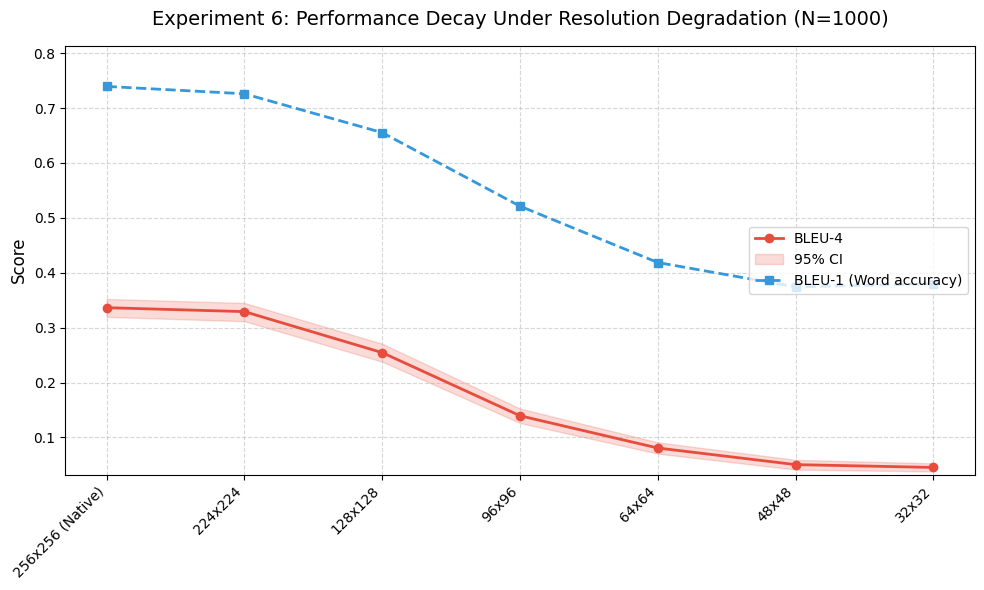

In [76]:
df_res = pd.DataFrame.from_dict(resolution_results, orient='index').sort_index(ascending=False)
display(df_res)

# Plotting a decay curve
fig, ax = plt.subplots(figsize=(10, 6))

x_vals = range(len(df_res))
ax.plot(x_vals, df_res['BLEU4'], marker='o', linewidth=2, color='#e74c3c', label='BLEU-4')
ax.fill_between(x_vals, df_res['B4_Lower'], df_res['B4_Upper'], color='#e74c3c', alpha=0.2, label='95% CI')

ax.plot(x_vals, df_res['BLEU1'], marker='s', linewidth=2, linestyle='--', color='#3498db', label='BLEU-1 (Word accuracy)')

# Dynamic Y-axis scaling based on data
y_min = min(df_res['B4_Lower']) * 0.85
y_max = max(df_res['BLEU1']) * 1.1
ax.set_ylim(y_min, y_max)

ax.set_xticks(x_vals)
ax.set_xticklabels(df_res['Label'], rotation=45, ha='right')
ax.set_title(f'Experiment 6: Performance Decay Under Resolution Degradation (N={SAMPLE_SIZE})', fontsize=14, pad=15)
ax.set_ylabel('Score', fontsize=12)
ax.grid(axis='both', linestyle='--', alpha=0.5)
ax.legend(loc='center right')

plt.tight_layout()
plt.show()

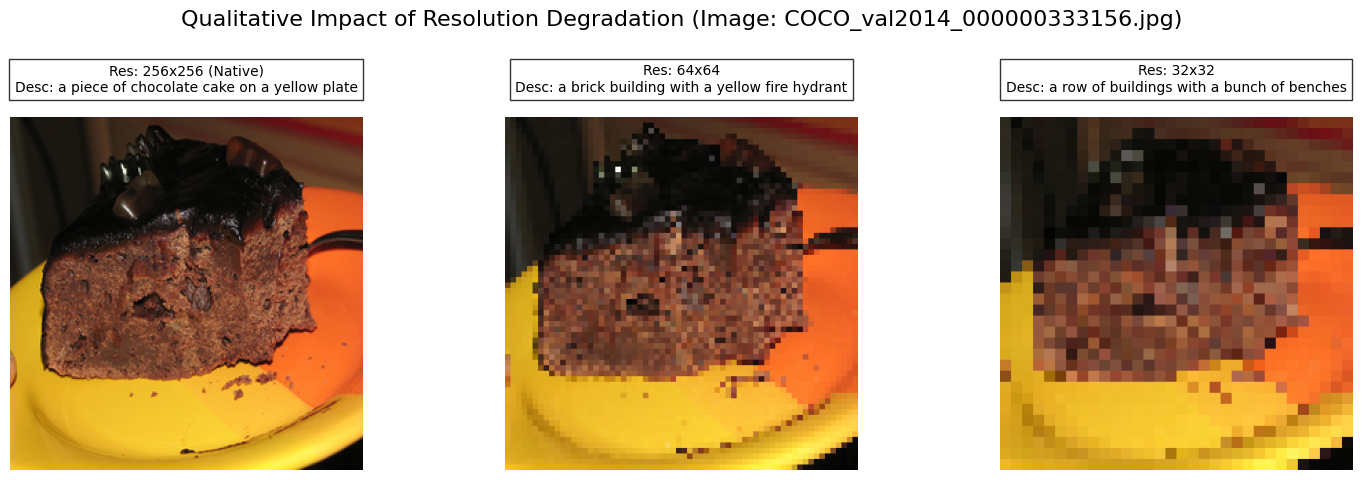

In [77]:
# Select one random image to visualize the physical degradation impact
sample_filename = random.choice(list(references_dict.keys()))
sample_path = os.path.join(VAL_IMAGES_DIR, sample_filename)

vis_resolutions = [None, 64, 32]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fig.suptitle(f'Qualitative Impact of Resolution Degradation (Image: {sample_filename})', fontsize=16, y=0.95)

for ax, res in zip(axes, vis_resolutions):
    img = get_degraded_image(sample_path, res)
    seq, _ = caption_image_beam_search(encoder, decoder, img, word_map, BEAM_SIZE)
    hyp = " ".join([rev_word_map[w] for w in seq if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}])
    
    ax.imshow(img)
    ax.axis('off')
    title = f"{res}x{res}" if res else "256x256 (Native)"
    
    ax.set_title(f"Res: {title}\nDesc: {hyp}", fontsize=10, wrap=True, pad=20, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.9]) 
plt.show()